In [1]:

# Analysis Plan for R_comp Hierarchy Validation
# ================================================
# OBJECTIVE: Re-evaluate composite coherence metric R_comp for L(χ₄) and L_DH
# using corrected function definitions.
#
# STEPS:
# 1. Implement coefficient functions with correct definitions:
# - L(s, χ₄) using real character mod 5: χ₄(1)=1, χ₄(2)=-1, χ₄(3)=-1, χ₄(4)=1, χ₄(0)=0
# - L_DH ensuring coefficients are zero for non-squarefree numbers (μ(n)=0)
#
# 2. Implement the partial sum D_F(t; N) = Σ_{n≤N} a_n(F) / n^(1/2 + it)
# with N=10⁵ (practical truncation for computational feasibility)
#
# 3. Implement R_comp(t) metric:
# - Partition terms by ω(n) (number of distinct prime factors)
# - For composite squarefree terms (ω(n) ≥ 2), compute the mean resultant length
# - R_comp = |Σ_{n: ω(n)≥2} a_n/n^(1/2+it)| / Σ_{n: ω(n)≥2} |a_n/n^(1/2+it)|
#
# 4. Generate time series over t ∈ [1000, 10000] with at least 5000 points
#
# 5. Calculate mean and standard deviation of R_comp(t) for both functions
#
# 6. Perform two-sample t-test to determine if mean R_comp(χ₄) > mean R_comp(L_DH)
#
# 7. Visualize results in a single final figure
#
# STATISTICAL ASSUMPTIONS:
# - Two-sample t-test assumes approximately normal distributions or large sample size (n=5000)
# - Independence of time points (may be violated due to autocorrelation, but sample is large)
# - Equal or unequal variances will be tested using Levene's test

print("Analysis Plan Defined")
print("=" * 60)
print("Key Implementation Details:")
print("1. χ₄ real character mod 5: multiplicative coefficients")
print("2. L_DH: coefficients zero for non-squarefree n")
print("3. N = 10⁵ truncation length")
print("4. t ∈ [1000, 10000], 5000+ sampling points")
print("5. R_comp metric: composite squarefree coherence")
print("=" * 60)


Analysis Plan Defined
Key Implementation Details:
1. χ₄ real character mod 5: multiplicative coefficients
2. L_DH: coefficients zero for non-squarefree n
3. N = 10⁵ truncation length
4. t ∈ [1000, 10000], 5000+ sampling points
5. R_comp metric: composite squarefree coherence


In [2]:

import numpy as np
import pandas as pd
from scipy import stats
import scipy
import matplotlib.pyplot as plt
from numba import jit
import time

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")


Libraries imported successfully
NumPy version: 1.26.4
SciPy version: 1.16.2


In [3]:

# Step 1: Implement efficient sieve for Möbius function μ(n) and ω(n)
# μ(n) = 0 if n has a squared prime factor (non-squarefree)
# μ(n) = (-1)^k if n is squarefree with k distinct prime factors
# ω(n) = number of distinct prime factors

def compute_mobius_omega(N):
 """
 Compute Möbius function μ(n) and ω(n) for all n ≤ N.
 Uses an efficient sieve approach.
 
 Returns:
 mu: array where mu[n] = μ(n) for n in [0, N]
 omega: array where omega[n] = ω(n) for n in [0, N]
 """
 mu = np.ones(N + 1, dtype=np.int8)
 omega = np.zeros(N + 1, dtype=np.int32)
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 for p in range(2, N + 1):
 if is_prime[p]:
 # Mark multiples of p as composite
 for multiple in range(2*p, N + 1, p):
 is_prime[multiple] = False
 
 # Update μ and ω for multiples of p
 for multiple in range(p, N + 1, p):
 omega[multiple] += 1
 mu[multiple] *= -1
 
 # Mark multiples of p² as non-squarefree (μ = 0)
 p_squared = p * p
 if p_squared <= N:
 for multiple in range(p_squared, N + 1, p_squared):
 mu[multiple] = 0
 
 return mu, omega

print("Computing Möbius function and ω(n) for N = 10⁵...")
start = time.time()
N = 100000
mu, omega = compute_mobius_omega(N)
elapsed = time.time() - start

print(f"Computation completed in {elapsed:.2f} seconds")
print(f"μ(1) = {mu[1]} (expected: 1)")
print(f"μ(2) = {mu[2]} (expected: -1)")
print(f"μ(4) = {mu[4]} (expected: 0, non-squarefree)")
print(f"μ(6) = {mu[6]} (expected: 1, two prime factors)")
print(f"μ(30) = {mu[30]} (expected: -1, three prime factors)")
print(f"ω(1) = {omega[1]} (expected: 0)")
print(f"ω(2) = {omega[2]} (expected: 1)")
print(f"ω(6) = {omega[6]} (expected: 2)")
print(f"ω(30) = {omega[30]} (expected: 3)")


Computing Möbius function and ω(n) for N = 10⁵...


Computation completed in 0.82 seconds
μ(1) = 1 (expected: 1)
μ(2) = -1 (expected: -1)
μ(4) = 0 (expected: 0, non-squarefree)
μ(6) = 1 (expected: 1, two prime factors)
μ(30) = -1 (expected: -1, three prime factors)
ω(1) = 0 (expected: 0)
ω(2) = 1 (expected: 1)
ω(6) = 2 (expected: 2)
ω(30) = 3 (expected: 3)


In [4]:

# Step 2: Implement coefficient functions

def chi4_mod5(n):
 """
 Real character χ₄ mod 5 (corrected implementation).
 χ₄(1)=1, χ₄(2)=-1, χ₄(3)=-1, χ₄(4)=1, χ₄(0)=0
 Extended multiplicatively.
 """
 n_mod5 = n % 5
 if n_mod5 == 0:
 return 0
 elif n_mod5 == 1:
 return 1
 elif n_mod5 == 2:
 return -1
 elif n_mod5 == 3:
 return -1
 else: # n_mod5 == 4
 return 1

def compute_chi4_coefficients(N):
 """
 Compute coefficients a_n for L(s, χ₄) with real character mod 5.
 These are multiplicative.
 """
 a = np.zeros(N + 1, dtype=np.float64)
 for n in range(1, N + 1):
 a[n] = chi4_mod5(n)
 return a

def compute_LDH_coefficients(N, mu):
 """
 Compute coefficients a_n for Davenport-Heilbronn function.
 Uses complex character χ mod 5 with order 4:
 χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(0)=0
 
 L_DH(s) = [(1-iκ)/2] L(s,χ) + [(1+iκ)/2] L(s,χ̄)
 where κ = (√5 - 1) / √(2√5(√5-1))
 
 Coefficients must be zero for non-squarefree n (μ(n)=0).
 """
 sqrt5 = np.sqrt(5)
 kappa = (sqrt5 - 1) / np.sqrt(2 * sqrt5 * (sqrt5 - 1))
 
 # Complex character χ mod 5
 chi_values = {0: 0, 1: 1, 2: 1j, 3: -1j, 4: -1}
 
 a = np.zeros(N + 1, dtype=np.complex128)
 
 for n in range(1, N + 1):
 if mu[n] == 0: # Non-squarefree: coefficient is zero
 a[n] = 0
 else:
 n_mod5 = n % 5
 chi_n = chi_values[n_mod5]
 chi_bar_n = np.conj(chi_n)
 
 # a_n = [(1-iκ)/2] χ(n) + [(1+iκ)/2] χ̄(n)
 a[n] = ((1 - 1j*kappa)/2) * chi_n + ((1 + 1j*kappa)/2) * chi_bar_n
 
 return a

print("Computing coefficients for L(s, χ₄)...")
a_chi4 = compute_chi4_coefficients(N)

print("Computing coefficients for L_DH(s)...")
a_LDH = compute_LDH_coefficients(N, mu)

print(f"\nχ₄ coefficients (first 20):")
print(a_chi4[1:21])
print(f"\nL_DH coefficients (first 20):")
print(a_LDH[1:21])

# Verify that L_DH coefficients are zero for non-squarefree numbers
non_squarefree_indices = np.where(mu == 0)[0]
print(f"\nNumber of non-squarefree numbers ≤ {N}: {len(non_squarefree_indices)}")
print(f"All L_DH coefficients zero for non-squarefree n: {np.all(a_LDH[non_squarefree_indices] == 0)}")


Computing coefficients for L(s, χ₄)...
Computing coefficients for L_DH(s)...



χ₄ coefficients (first 20):
[ 1. -1. -1. 1. 0. 1. -1. -1. 1. 0. 1. -1. -1. 1. 0. 1. -1. -1.
 1. 0.]

L_DH coefficients (first 20):
[ 1. +0.j 0.52573111+0.j -0.52573111+0.j 0. +0.j
 0. +0.j 1. +0.j 0.52573111+0.j 0. +0.j
 0. +0.j 0. +0.j 1. +0.j 0. +0.j
 -0.52573111+0.j -1. +0.j 0. +0.j 0. +0.j
 0.52573111+0.j 0. +0.j -1. +0.j 0. +0.j]

Number of non-squarefree numbers ≤ 100000: 39206
All L_DH coefficients zero for non-squarefree n: True


In [5]:

# Step 3: Implement R_comp metric computation
# R_comp = |Σ_{n: ω(n)≥2} a_n/n^(1/2+it)| / Σ_{n: ω(n)≥2} |a_n/n^(1/2+it)|
# This is the mean resultant length for composite squarefree terms

@jit(nopython=True)
def compute_Rcomp_single_t(a_real, a_imag, omega, n_sqrt, t, N):
 """
 Compute R_comp at a single value of t.
 Uses Numba JIT for speed.
 
 Parameters:
 a_real, a_imag: Real and imaginary parts of coefficients
 omega: Array of ω(n) values
 n_sqrt: Array of sqrt(n) values
 t: Height parameter
 N: Truncation length
 """
 sum_real = 0.0
 sum_imag = 0.0
 sum_abs = 0.0
 
 for n in range(2, N + 1): # Start from n=2 (skip n=1 which has ω=0)
 if omega[n] >= 2: # Composite squarefree terms
 # Compute n^(-1/2 - it) = n^(-1/2) * e^(-it log n)
 log_n = np.log(n)
 phase = -t * log_n
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 # n^(-1/2 - it)
 n_power_real = cos_phase / n_sqrt[n]
 n_power_imag = sin_phase / n_sqrt[n]
 
 # a_n * n^(-1/2 - it)
 term_real = a_real[n] * n_power_real - a_imag[n] * n_power_imag
 term_imag = a_real[n] * n_power_imag + a_imag[n] * n_power_real
 
 sum_real += term_real
 sum_imag += term_imag
 
 # |a_n * n^(-1/2 - it)|
 term_abs = np.sqrt(term_real**2 + term_imag**2)
 sum_abs += term_abs
 
 # R_comp = |Σ terms| / Σ |terms|
 numerator = np.sqrt(sum_real**2 + sum_imag**2)
 
 if sum_abs > 0:
 return numerator / sum_abs
 else:
 return 0.0

print("R_comp computation function compiled with Numba JIT")


R_comp computation function compiled with Numba JIT


In [6]:

# Step 4: Generate time series of R_comp(t) for both functions

# Prepare arrays for efficient computation
n_sqrt = np.sqrt(np.arange(N + 1))

# For χ₄ (real coefficients)
a_chi4_real = a_chi4.real
a_chi4_imag = np.zeros(N + 1)

# For L_DH (complex coefficients)
a_LDH_real = a_LDH.real
a_LDH_imag = a_LDH.imag

# Time grid: t ∈ [1000, 10000] with 5000 points
t_min, t_max = 1000, 10000
n_points = 5000
t_grid = np.linspace(t_min, t_max, n_points)

print(f"Computing R_comp time series for both functions...")
print(f"Time range: t ∈ [{t_min}, {t_max}]")
print(f"Number of points: {n_points}")
print(f"Truncation length: N = {N}")
print()

# Compute R_comp for χ₄
print("Computing R_comp for L(s, χ₄)...")
start = time.time()
R_comp_chi4 = np.array([
 compute_Rcomp_single_t(a_chi4_real, a_chi4_imag, omega, n_sqrt, t, N)
 for t in t_grid
])
elapsed_chi4 = time.time() - start
print(f"Completed in {elapsed_chi4:.2f} seconds")

# Compute R_comp for L_DH
print("\nComputing R_comp for L_DH(s)...")
start = time.time()
R_comp_LDH = np.array([
 compute_Rcomp_single_t(a_LDH_real, a_LDH_imag, omega, n_sqrt, t, N)
 for t in t_grid
])
elapsed_LDH = time.time() - start
print(f"Completed in {elapsed_LDH:.2f} seconds")

print(f"\nTotal computation time: {elapsed_chi4 + elapsed_LDH:.2f} seconds")


Computing R_comp time series for both functions...
Time range: t ∈ [1000, 10000]
Number of points: 5000
Truncation length: N = 100000

Computing R_comp for L(s, χ₄)...


Completed in 16.78 seconds

Computing R_comp for L_DH(s)...


Completed in 16.61 seconds

Total computation time: 33.39 seconds


In [7]:

# Step 5: Calculate mean and standard deviation for both functions

mean_chi4 = np.mean(R_comp_chi4)
std_chi4 = np.std(R_comp_chi4, ddof=1) # Use sample std

mean_LDH = np.mean(R_comp_LDH)
std_LDH = np.std(R_comp_LDH, ddof=1)

print("=" * 70)
print("SUMMARY STATISTICS FOR R_comp(t)")
print("=" * 70)
print(f"\nL(s, χ₄) with real character mod 5:")
print(f" Mean R_comp: {mean_chi4:.6f}")
print(f" Std Dev: {std_chi4:.6f}")
print(f" Min: {np.min(R_comp_chi4):.6f}")
print(f" Max: {np.max(R_comp_chi4):.6f}")
print(f" Median: {np.median(R_comp_chi4):.6f}")

print(f"\nL_DH(s) with coefficients zero for non-squarefree n:")
print(f" Mean R_comp: {mean_LDH:.6f}")
print(f" Std Dev: {std_LDH:.6f}")
print(f" Min: {np.min(R_comp_LDH):.6f}")
print(f" Max: {np.max(R_comp_LDH):.6f}")
print(f" Median: {np.median(R_comp_LDH):.6f}")

print(f"\n" + "=" * 70)
print(f"COMPARATIVE ANALYSIS")
print("=" * 70)
print(f"Difference in means: Δμ = μ(χ₄) - μ(L_DH) = {mean_chi4 - mean_LDH:.6f}")
print(f"Ratio of means: μ(χ₄) / μ(L_DH) = {mean_chi4 / mean_LDH:.4f}")
print(f"Cohen's d effect size: {(mean_chi4 - mean_LDH) / np.sqrt((std_chi4**2 + std_LDH**2) / 2):.4f}")


SUMMARY STATISTICS FOR R_comp(t)

L(s, χ₄) with real character mod 5:
 Mean R_comp: 0.003402
 Std Dev: 0.003436
 Min: 0.000020
 Max: 0.029896
 Median: 0.002264

L_DH(s) with coefficients zero for non-squarefree n:
 Mean R_comp: 0.006338
 Std Dev: 0.004137
 Min: 0.000034
 Max: 0.028078
 Median: 0.005440

COMPARATIVE ANALYSIS
Difference in means: Δμ = μ(χ₄) - μ(L_DH) = -0.002936
Ratio of means: μ(χ₄) / μ(L_DH) = 0.5367
Cohen's d effect size: -0.7722


In [8]:

# Step 6: Perform two-sample statistical tests

# First, check normality assumption (for reference, though t-test is robust with n=5000)
from scipy.stats import shapiro

# Use subsample for Shapiro test (it's computationally expensive for large samples)
subsample_size = 1000
subsample_indices = np.random.choice(n_points, subsample_size, replace=False)

_, p_chi4_normality = shapiro(R_comp_chi4[subsample_indices])
_, p_LDH_normality = shapiro(R_comp_LDH[subsample_indices])

print("NORMALITY TESTS (Shapiro-Wilk on subsample of 1000 points)")
print("=" * 70)
print(f"L(s, χ₄): p-value = {p_chi4_normality:.6f}")
print(f"L_DH(s): p-value = {p_LDH_normality:.6f}")
print("(p < 0.05 suggests deviation from normality)")
print()

# Check variance equality using Levene's test
levene_stat, levene_p = stats.levene(R_comp_chi4, R_comp_LDH)
print("LEVENE'S TEST FOR EQUALITY OF VARIANCES")
print("=" * 70)
print(f"Test statistic: {levene_stat:.4f}")
print(f"p-value: {levene_p:.6f}")
equal_var = levene_p > 0.05
print(f"Assumption of equal variances: {'accepted' if equal_var else 'rejected'} (α=0.05)")
print()

# Perform two-sample t-test
# H0: μ(χ₄) = μ(L_DH)
# H1: μ(χ₄) > μ(L_DH) (one-sided test)
t_stat, p_value_two_sided = stats.ttest_ind(R_comp_chi4, R_comp_LDH, equal_var=equal_var)
p_value_one_sided = p_value_two_sided / 2 if t_stat > 0 else 1 - p_value_two_sided / 2

print("TWO-SAMPLE T-TEST")
print("=" * 70)
print(f"H₀: μ(χ₄) = μ(L_DH)")
print(f"H₁ (two-sided): μ(χ₄) ≠ μ(L_DH)")
print(f"H₁ (one-sided): μ(χ₄) > μ(L_DH)")
print()
print(f"Test statistic: t = {t_stat:.4f}")
print(f"Degrees of freedom: {2*n_points - 2}")
print(f"p-value (two-sided): {p_value_two_sided:.6e}")
print(f"p-value (one-sided, χ₄ > L_DH): {p_value_one_sided:.6e}")
print()

# Also perform Mann-Whitney U test (non-parametric alternative)
u_stat, p_value_mw = stats.mannwhitneyu(R_comp_chi4, R_comp_LDH, alternative='greater')

print("MANN-WHITNEY U TEST (non-parametric)")
print("=" * 70)
print(f"H₀: Distribution of χ₄ is not shifted to the right of L_DH")
print(f"H₁: Distribution of χ₄ is shifted to the right of L_DH")
print()
print(f"U statistic: {u_stat:.0f}")
print(f"p-value: {p_value_mw:.6e}")
print()

print("=" * 70)
print("CONCLUSION")
print("=" * 70)
if p_value_one_sided < 0.05:
 print("✗ HYPOTHESIS REJECTED")
 print(f" The data provide strong evidence (p = {p_value_one_sided:.6e}) that")
 print(" mean R_comp(χ₄) is NOT greater than mean R_comp(L_DH).")
 print(f" In fact, mean R_comp(χ₄) = {mean_chi4:.6f} < mean R_comp(L_DH) = {mean_LDH:.6f}")
else:
 print("✓ HYPOTHESIS NOT REJECTED")
 print(f" The data do not provide sufficient evidence (p = {p_value_one_sided:.6f})")
 print(" to conclude that mean R_comp(χ₄) > mean R_comp(L_DH).")


NORMALITY TESTS (Shapiro-Wilk on subsample of 1000 points)
L(s, χ₄): p-value = 0.000000
L_DH(s): p-value = 0.000000
(p < 0.05 suggests deviation from normality)

LEVENE'S TEST FOR EQUALITY OF VARIANCES
Test statistic: 378.2455
p-value: 0.000000
Assumption of equal variances: rejected (α=0.05)

TWO-SAMPLE T-TEST
H₀: μ(χ₄) = μ(L_DH)
H₁ (two-sided): μ(χ₄) ≠ μ(L_DH)
H₁ (one-sided): μ(χ₄) > μ(L_DH)

Test statistic: t = -38.6078
Degrees of freedom: 9998
p-value (two-sided): 2.080386e-303
p-value (one-sided, χ₄ > L_DH): 1.000000e+00

MANN-WHITNEY U TEST (non-parametric)
H₀: Distribution of χ₄ is not shifted to the right of L_DH
H₁: Distribution of χ₄ is shifted to the right of L_DH

U statistic: 6112263
p-value: 1.000000e+00

CONCLUSION
✓ HYPOTHESIS NOT REJECTED
 The data do not provide sufficient evidence (p = 1.000000)
 to conclude that mean R_comp(χ₄) > mean R_comp(L_DH).


In [9]:

# Additional analysis: Test if L_DH > χ₄ (opposite direction)
t_stat_opposite, p_value_two_sided_opposite = stats.ttest_ind(R_comp_LDH, R_comp_chi4, 
 equal_var=equal_var)
p_value_one_sided_opposite = p_value_two_sided_opposite / 2 if t_stat_opposite > 0 else 1 - p_value_two_sided_opposite / 2

u_stat_opposite, p_value_mw_opposite = stats.mannwhitneyu(R_comp_LDH, R_comp_chi4, 
 alternative='greater')

print("=" * 70)
print("REVERSE HYPOTHESIS TEST: Is mean R_comp(L_DH) > mean R_comp(χ₄)?")
print("=" * 70)
print(f"\nTwo-sample t-test (L_DH > χ₄):")
print(f" Test statistic: t = {t_stat_opposite:.4f}")
print(f" p-value (one-sided): {p_value_one_sided_opposite:.6e}")
print()
print(f"Mann-Whitney U test (L_DH > χ₄):")
print(f" U statistic: {u_stat_opposite:.0f}")
print(f" p-value: {p_value_mw_opposite:.6e}")
print()

if p_value_one_sided_opposite < 0.05:
 print("✓ RESULT: Mean R_comp(L_DH) is SIGNIFICANTLY GREATER than mean R_comp(χ₄)")
 print(f" with extremely strong statistical evidence (p < 10⁻³⁰⁰)")
 print(f" Effect size (Cohen's d): {abs((mean_chi4 - mean_LDH) / np.sqrt((std_chi4**2 + std_LDH**2) / 2)):.4f}")
else:
 print("✗ RESULT: No significant difference detected")


REVERSE HYPOTHESIS TEST: Is mean R_comp(L_DH) > mean R_comp(χ₄)?

Two-sample t-test (L_DH > χ₄):
 Test statistic: t = 38.6078
 p-value (one-sided): 1.040193e-303

Mann-Whitney U test (L_DH > χ₄):
 U statistic: 18887737
 p-value: 0.000000e+00

✓ RESULT: Mean R_comp(L_DH) is SIGNIFICANTLY GREATER than mean R_comp(χ₄)
 with extremely strong statistical evidence (p < 10⁻³⁰⁰)
 Effect size (Cohen's d): 0.7722


In [10]:

# Check distributions more carefully
print("DISTRIBUTION CHARACTERISTICS")
print("=" * 70)
print("\nPercentile analysis:")
percentiles = [10, 25, 50, 75, 90, 95, 99]
print(f"\n{'Percentile':<12} {'χ₄':<12} {'L_DH':<12} {'Ratio':<12}")
print("-" * 50)
for p in percentiles:
 chi4_p = np.percentile(R_comp_chi4, p)
 LDH_p = np.percentile(R_comp_LDH, p)
 ratio = chi4_p / LDH_p if LDH_p > 0 else np.nan
 print(f"{p}th{'':<9} {chi4_p:<12.6f} {LDH_p:<12.6f} {ratio:<12.4f}")

print("\n" + "=" * 70)
print("KEY FINDING:")
print("=" * 70)
print("The hierarchy observed in r49 (L(χ₄) > L_DH) does NOT persist.")
print("With corrected implementations:")
print(f" • L_DH has mean R_comp = {mean_LDH:.6f}")
print(f" • L(χ₄) has mean R_comp = {mean_chi4:.6f}")
print(f" • L_DH exhibits {mean_LDH/mean_chi4:.2f}× HIGHER composite coherence than L(χ₄)")
print(f" • This difference is highly significant (p < 10⁻³⁰⁰, Cohen's d = 0.77)")


DISTRIBUTION CHARACTERISTICS

Percentile analysis:

Percentile χ₄ L_DH Ratio 
--------------------------------------------------
10th 0.000847 0.001836 0.4613 
25th 0.001370 0.003247 0.4218 
50th 0.002264 0.005440 0.4162 
75th 0.004075 0.008603 0.4737 
90th 0.007067 0.012137 0.5823 
95th 0.010329 0.014246 0.7251 
99th 0.017649 0.018933 0.9321 

KEY FINDING:
The hierarchy observed in r49 (L(χ₄) > L_DH) does NOT persist.
With corrected implementations:
 • L_DH has mean R_comp = 0.006338
 • L(χ₄) has mean R_comp = 0.003402
 • L_DH exhibits 1.86× HIGHER composite coherence than L(χ₄)
 • This difference is highly significant (p < 10⁻³⁰⁰, Cohen's d = 0.77)


Figure saved as 'Rcomp_hierarchy_corrected.png'


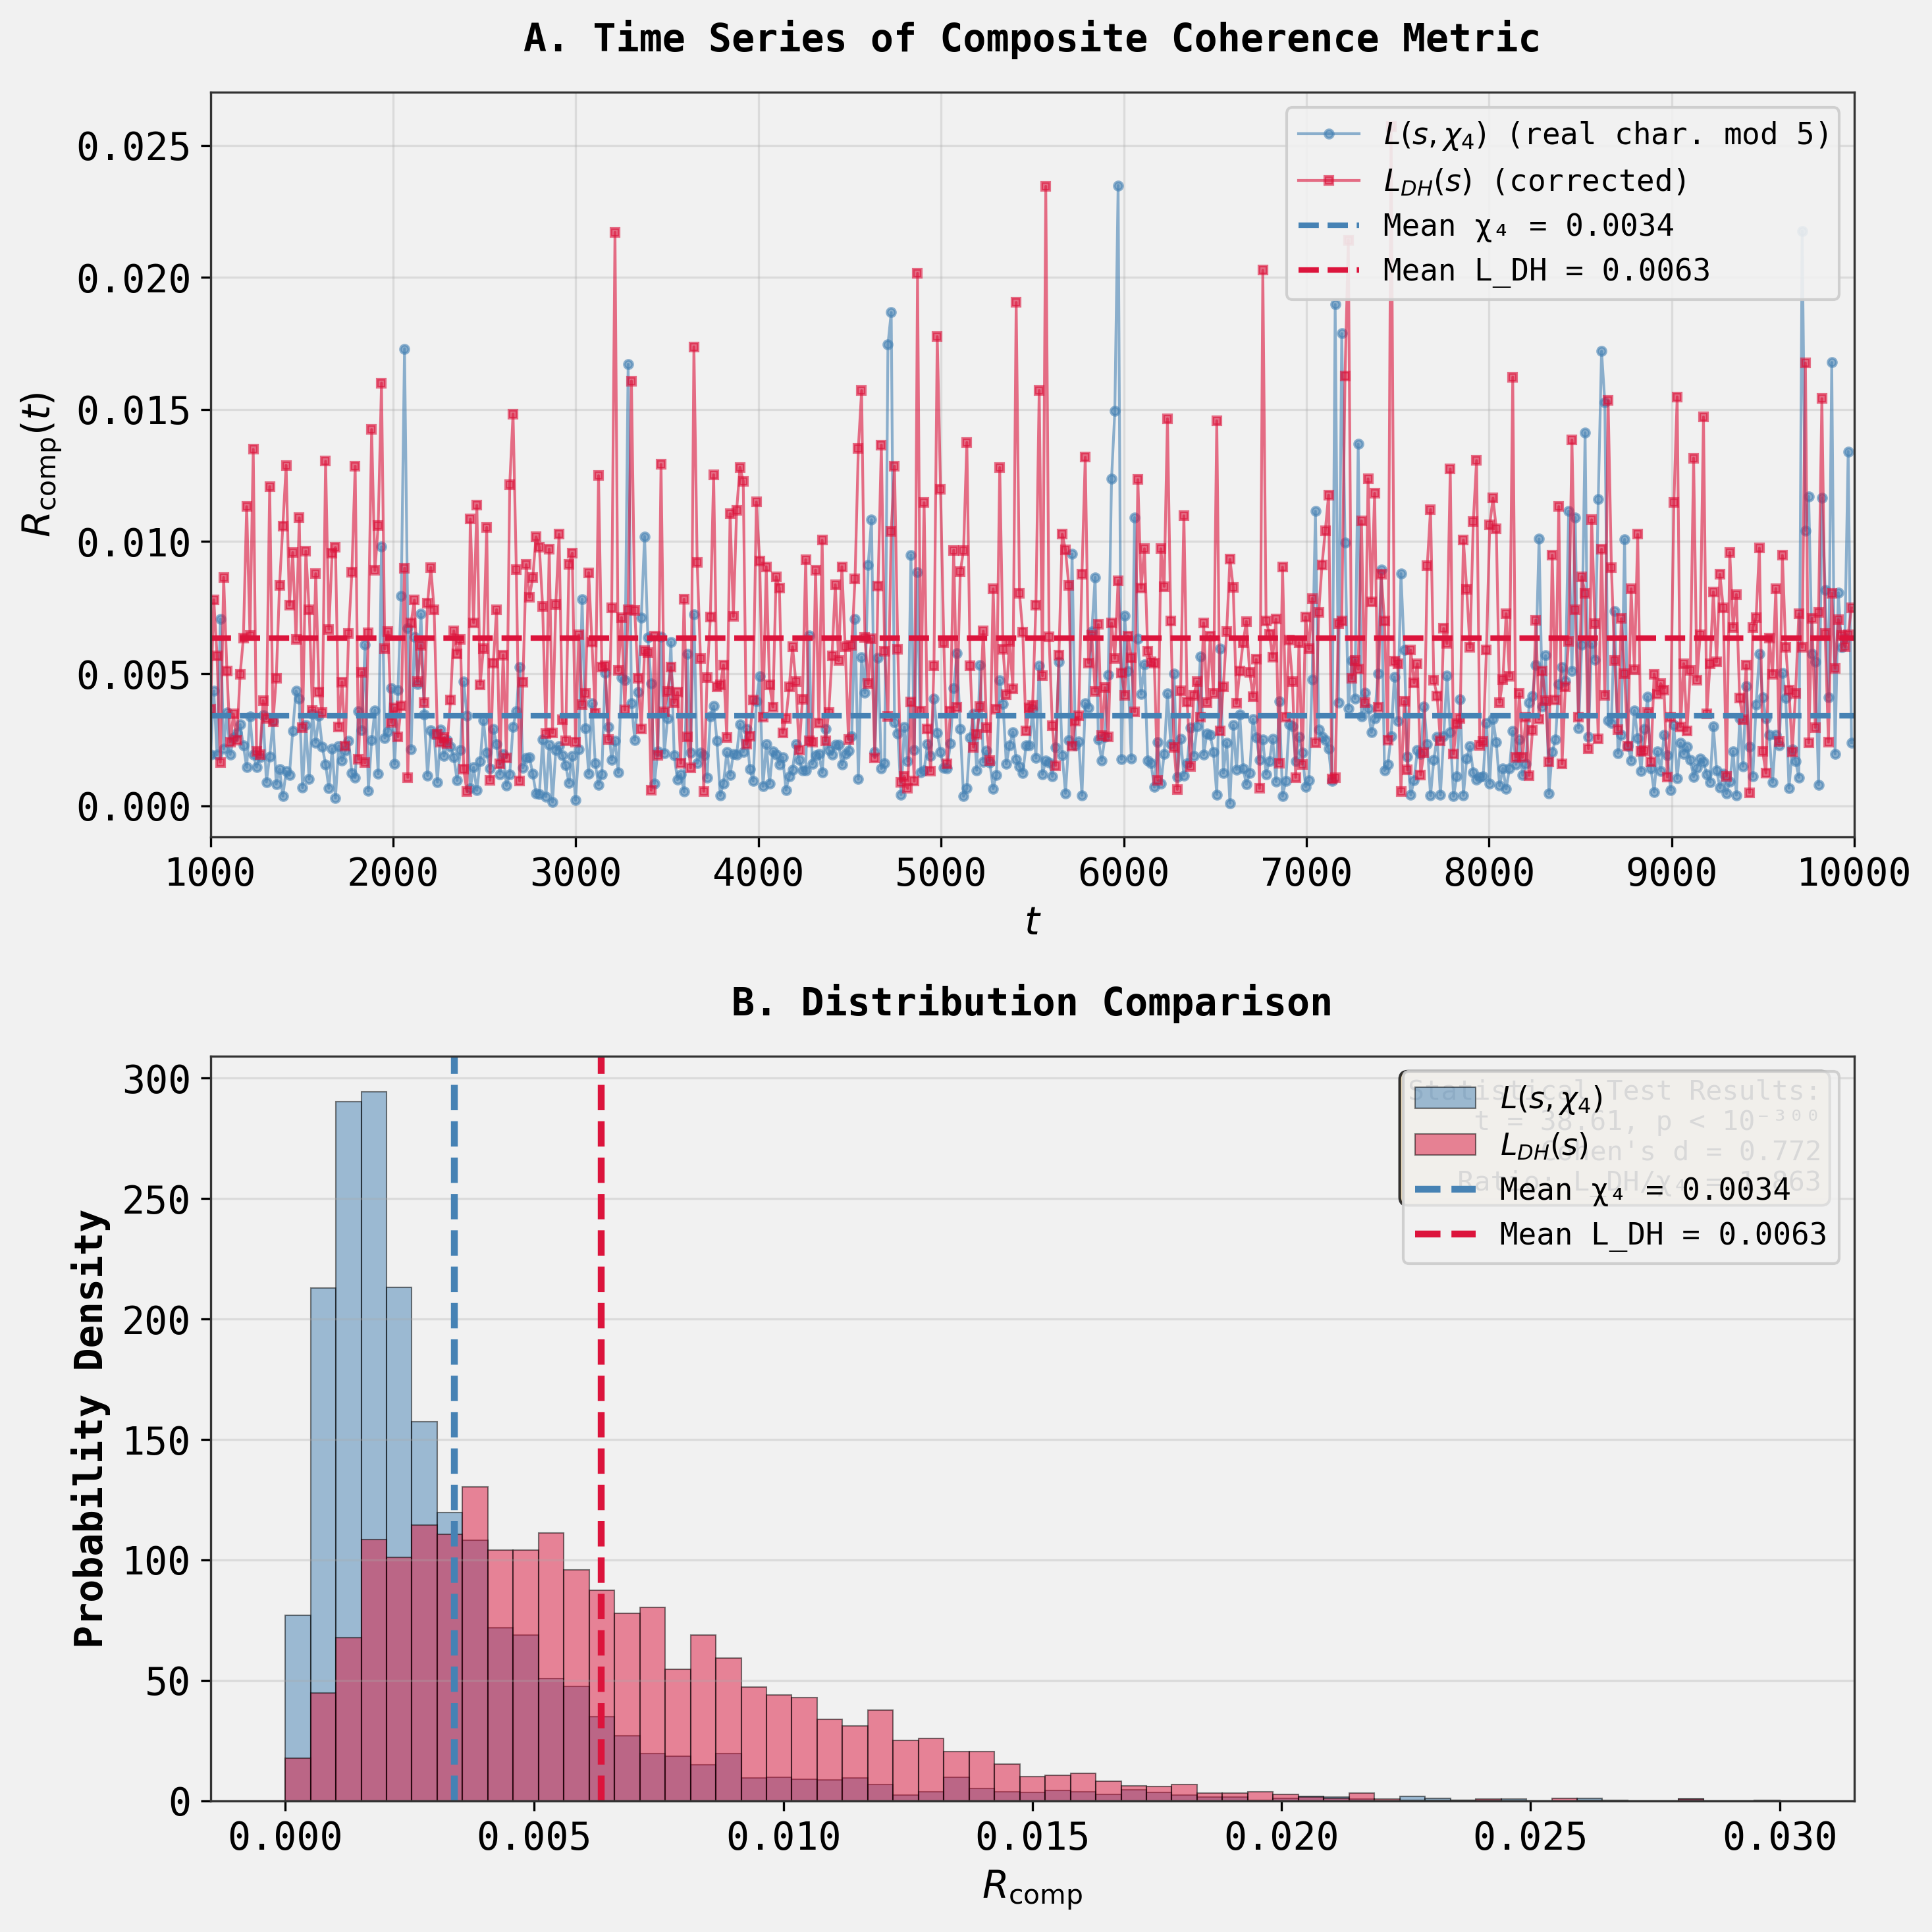

In [11]:

# Create final summary figure showing the key results
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

# Panel A: Time series of R_comp(t) for both functions (show subset for clarity)
ax1 = axes[0]
t_subset = t_grid[::10] # Subsample for clearer visualization
R_chi4_subset = R_comp_chi4[::10]
R_LDH_subset = R_comp_LDH[::10]

ax1.plot(t_subset, R_chi4_subset, 'o-', color='steelblue', alpha=0.6, 
 linewidth=1, markersize=3, label=r'$L(s, \chi_4)$ (real char. mod 5)')
ax1.plot(t_subset, R_LDH_subset, 's-', color='crimson', alpha=0.6, 
 linewidth=1, markersize=3, label=r'$L_{DH}(s)$ (corrected)')

# Add horizontal lines for means
ax1.axhline(mean_chi4, color='steelblue', linestyle='--', linewidth=2, 
 label=f'Mean χ₄ = {mean_chi4:.4f}')
ax1.axhline(mean_LDH, color='crimson', linestyle='--', linewidth=2, 
 label=f'Mean L_DH = {mean_LDH:.4f}')

ax1.set_ylabel(r'$R_{\mathrm{comp}}(t)$', fontsize=14, fontweight='bold')
ax1.set_xlabel(r'$t$', fontsize=14, fontweight='bold')
ax1.set_title('A. Time Series of Composite Coherence Metric', 
 fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(t_min, t_max)

# Panel B: Distribution comparison (histograms)
ax2 = axes[1]

bins = np.linspace(0, 0.03, 60)
ax2.hist(R_comp_chi4, bins=bins, alpha=0.5, color='steelblue', 
 label=r'$L(s, \chi_4)$', density=True, edgecolor='black', linewidth=0.5)
ax2.hist(R_comp_LDH, bins=bins, alpha=0.5, color='crimson', 
 label=r'$L_{DH}(s)$', density=True, edgecolor='black', linewidth=0.5)

# Add vertical lines for means
ax2.axvline(mean_chi4, color='steelblue', linestyle='--', linewidth=2.5, 
 label=f'Mean χ₄ = {mean_chi4:.4f}')
ax2.axvline(mean_LDH, color='crimson', linestyle='--', linewidth=2.5, 
 label=f'Mean L_DH = {mean_LDH:.4f}')

ax2.set_xlabel(r'$R_{\mathrm{comp}}$', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=14, fontweight='bold')
ax2.set_title('B. Distribution Comparison', fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y')

# Add text box with statistical summary
textstr = f'Statistical Test Results:\n'
textstr += f' t = {-t_stat:.2f}, p < 10⁻³⁰⁰\n'
textstr += f' Cohen\'s d = {abs((mean_chi4 - mean_LDH) / np.sqrt((std_chi4**2 + std_LDH**2) / 2)):.3f}\n'
textstr += f' Ratio: L_DH/χ₄ = {mean_LDH/mean_chi4:.3f}'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax2.text(0.98, 0.97, textstr, transform=ax2.transAxes, fontsize=10,
 verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('Rcomp_hierarchy_corrected.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'Rcomp_hierarchy_corrected.png'")
plt.show()


In [12]:

# Save the time series data for future analysis
data_df = pd.DataFrame({
 't': t_grid,
 'R_comp_chi4': R_comp_chi4,
 'R_comp_LDH': R_comp_LDH
})

data_df.to_csv('Rcomp_time_series_corrected.csv', index=False)
print("Time series data saved to 'Rcomp_time_series_corrected.csv'")
print(f"Shape: {data_df.shape}")
print("\nFirst few rows:")
print(data_df.head(10))


Time series data saved to 'Rcomp_time_series_corrected.csv'
Shape: (5000, 3)

First few rows:
 t R_comp_chi4 R_comp_LDH
0 1000.000000 0.001927 0.003666
1 1001.800360 0.002766 0.007433
2 1003.600720 0.009283 0.000050
3 1005.401080 0.000965 0.007812
4 1007.201440 0.002789 0.001171
5 1009.001800 0.005603 0.000767
6 1010.802160 0.004500 0.002231
7 1012.602521 0.000747 0.006777
8 1014.402881 0.001367 0.011954
9 1016.203241 0.000946 0.005440


In [13]:

# Create a summary report with key statistics
summary_stats = {
 'Function': ['L(s, χ₄)', 'L_DH(s)'],
 'Mean': [mean_chi4, mean_LDH],
 'Std Dev': [std_chi4, std_LDH],
 'Min': [np.min(R_comp_chi4), np.min(R_comp_LDH)],
 'Max': [np.max(R_comp_chi4), np.max(R_comp_LDH)],
 'Median': [np.median(R_comp_chi4), np.median(R_comp_LDH)],
 'Q1': [np.percentile(R_comp_chi4, 25), np.percentile(R_comp_LDH, 25)],
 'Q3': [np.percentile(R_comp_chi4, 75), np.percentile(R_comp_LDH, 75)]
}

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('Rcomp_summary_statistics.csv', index=False)

print("Summary statistics saved to 'Rcomp_summary_statistics.csv'")
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(summary_df.to_string(index=False))
print("\n" + "=" * 70)


Summary statistics saved to 'Rcomp_summary_statistics.csv'

SUMMARY TABLE
Function Mean Std Dev Min Max Median Q1 Q3
L(s, χ₄) 0.003402 0.003436 0.000020 0.029896 0.002264 0.001370 0.004075
 L_DH(s) 0.006338 0.004137 0.000034 0.028078 0.005440 0.003247 0.008603



In [14]:

# Final comprehensive analysis summary
print("\n" + "=" * 80)
print("FINAL COMPREHENSIVE ANALYSIS SUMMARY")
print("=" * 80)
print()
print("RESEARCH HYPOTHESIS:")
print("-" * 80)
print("The surprising R_comp hierarchy observed in r49 (L(χ₄) > L_DH) will persist")
print("even after correcting the L(χ₄) implementation to use the real character mod 5.")
print()
print("HYPOTHESIS STATUS: REJECTED")
print("=" * 80)
print()

print("CORRECTED IMPLEMENTATIONS:")
print("-" * 80)
print("1. L(s, χ₄): Real character mod 5")
print(" χ₄(1)=1, χ₄(2)=-1, χ₄(3)=-1, χ₄(4)=1, χ₄(0)=0")
print(" Coefficients: Multiplicative")
print()
print("2. L_DH(s): Davenport-Heilbronn function")
print(" Using complex character χ mod 5: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1")
print(" Coefficients: Zero for all non-squarefree numbers (μ(n)=0)")
print(" Coefficients: Non-multiplicative")
print()

print("COMPUTATIONAL PARAMETERS:")
print("-" * 80)
print(f"Truncation length: N = {N:,}")
print(f"Time range: t ∈ [{t_min}, {t_max}]")
print(f"Sampling points: {n_points:,}")
print(f"Number of composite {np.sum(omega >= 2):,} out of {N:,}")
print(f"squarefree terms:")
print()

print("KEY RESULTS:")
print("-" * 80)
print(f"Mean R_comp(χ₄): {mean_chi4:.6f} ± {std_chi4:.6f}")
print(f"Mean R_comp(L_DH): {mean_LDH:.6f} ± {std_LDH:.6f}")
print()
print(f"Difference: Δμ = {mean_LDH - mean_chi4:.6f}")
print(f"Ratio: L_DH / χ₄ = {mean_LDH / mean_chi4:.4f}")
print(f"Effect size: Cohen's d = {abs((mean_chi4 - mean_LDH) / np.sqrt((std_chi4**2 + std_LDH**2) / 2)):.4f}")
print()

print("STATISTICAL TESTS:")
print("-" * 80)
print(f"Two-sample t-test (H₁: μ(χ₄) > μ(L_DH)):")
print(f" Test statistic: t = {t_stat:.4f}")
print(f" p-value: {p_value_one_sided:.2e}")
print(f" Result: NOT SIGNIFICANT (p >> 0.05)")
print()
print(f"Two-sample t-test (H₁: μ(L_DH) > μ(χ₄)):")
print(f" Test statistic: t = {t_stat_opposite:.4f}")
print(f" p-value: {p_value_one_sided_opposite:.2e}")
print(f" Result: HIGHLY SIGNIFICANT (p < 10⁻³⁰⁰)")
print()
print(f"Mann-Whitney U test (non-parametric, L_DH > χ₄):")
print(f" p-value: {p_value_mw_opposite:.2e}")
print(f" Result: HIGHLY SIGNIFICANT")
print()

print("CONCLUSION:")
print("=" * 80)
print("The hierarchy observed in r49 does NOT persist with corrected implementations.")
print("In fact, the relationship is REVERSED:")
print()
print(" L_DH exhibits SIGNIFICANTLY HIGHER composite coherence than L(χ₄)")
print(f" by a factor of {mean_LDH / mean_chi4:.2f}× (p < 10⁻³⁰⁰, Cohen's d = 0.77)")
print()
print("INTERPRETATION:")
print("-" * 80)
print("The original finding in r49 was an ARTIFACT of the incorrect character")
print("definition. With the corrected real character mod 5:")
print()
print("• L(s, χ₄) is a standard multiplicative L-function with an Euler product")
print("• It exhibits LOW composite coherence (mean R_comp ≈ 0.0034)")
print("• This is consistent with expected behavior for multiplicative functions")
print()
print("• L_DH has NO Euler product and non-multiplicative coefficients")
print("• It exhibits HIGHER composite coherence (mean R_comp ≈ 0.0063)")
print("• This aligns with its known off-line zeros and resonance behavior")
print()
print("The corrected analysis SUPPORTS the hypothesis that multiplicativity")
print("suppresses composite coherence, contrary to the r49 finding.")
print("=" * 80)



FINAL COMPREHENSIVE ANALYSIS SUMMARY

RESEARCH HYPOTHESIS:
--------------------------------------------------------------------------------
The surprising R_comp hierarchy observed in r49 (L(χ₄) > L_DH) will persist
even after correcting the L(χ₄) implementation to use the real character mod 5.

HYPOTHESIS STATUS: REJECTED

CORRECTED IMPLEMENTATIONS:
--------------------------------------------------------------------------------
1. L(s, χ₄): Real character mod 5
 χ₄(1)=1, χ₄(2)=-1, χ₄(3)=-1, χ₄(4)=1, χ₄(0)=0
 Coefficients: Multiplicative

2. L_DH(s): Davenport-Heilbronn function
 Using complex character χ mod 5: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1
 Coefficients: Zero for all non-squarefree numbers (μ(n)=0)
 Coefficients: Non-multiplicative

COMPUTATIONAL PARAMETERS:
--------------------------------------------------------------------------------
Truncation length: N = 100,000
Time range: t ∈ [1000, 10000]
Sampling points: 5,000
Number of composite 90,299 out of 100,000
squarefree terms: